In [1]:
# Install the ART library (provides adversarial attacks)
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.8 MB/s eta 0:00:00


In [2]:
# Import libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from os import listdir
import cv2
import natsort
from sklearn.model_selection import train_test_split

# Print the version of tensorflow
print("TensorFlow version:{}".format(tf.__version__))

TensorFlow version:2.19.0


In [3]:
# Download the dataset
!wget https://www.idahofallshighered.org/vakanski/Codes_Data/Scenes.zip

--2026-03-24 15:26:48--  https://www.idahofallshighered.org/vakanski/Codes_Data/Scenes.zip
Resolving www.idahofallshighered.org (www.idahofallshighered.org)... 50.6.2.30
Connecting to www.idahofallshighered.org (www.idahofallshighered.org)|50.6.2.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53412210 (51M) [application/zip]
Saving to: ‘Scenes.zip’

Scenes.zip          100%[===================>]  50.94M   115MB/s    in 0.4s    

2026-03-24 15:26:49 (115 MB/s) - ‘Scenes.zip’ saved [53412210/53412210]



In [4]:
# Uncompress the dataset
!unzip -uq "Scenes.zip" -d "sample_data/"

In [5]:
# Function to load the images and the labels from the dataset
def load_images_and_labels(directory):

    imgs_list = []
    labels_list = []

    # List of all subfolders in the directory
    subfolders_list_1 = listdir(directory)
    # Make sure that the subfolders are sorted
    subfolders_list = natsort.natsorted(subfolders_list_1)

    # Assign a label to each folder with images (0 to the first folder)
    lab = 0
    for subfolder_name in subfolders_list:
        sub_dir_path = directory + '/' + subfolder_name

        # Read the images as numpy arrays
        imagesList = listdir(sub_dir_path)
        for i in range(len(imagesList)):
          tmp_img = cv2.imread(os.path.join(sub_dir_path, imagesList[i]))
          # Resize all images to 128 x 128 pixels
          resized_img = cv2.resize(tmp_img, (128, 128))
          img_arr = np.array(resized_img)
          imgs_list.append(img_arr.astype(float))
          labels_list.append(lab)
        lab += 1

    # Convert the lists to numpy arrays
    imgs = np.asarray(imgs_list)
    labels = np.asarray(labels_list)

    return imgs, labels

# Use the above function to load the images and labels
all_images, all_labels = load_images_and_labels('sample_data/Scenes')

In [6]:
# Split into train, test, and validation sets
trainval_images, test_images, trainval_labels, test_labels = train_test_split(all_images, all_labels, test_size=0.2, random_state=11)
train_images, val_images, train_labels, val_labels = train_test_split(trainval_images, trainval_labels, test_size=0.2, random_state=12)
del all_images

In [7]:
# Display the shapes of train, validation, and test datasets
print('Images train shape: {} - Labels train shape: {}'.format(train_images.shape, train_labels.shape))
print('Images validation shape: {} - Labels validation shape: {}'.format(val_images.shape, val_labels.shape))
print('Images test shape: {} - Labels test shape: {}'.format(test_images.shape, test_labels.shape))

# Display the range of images
print('\nMax pixel value', np.max(train_images))
print('Min pixel value', np.min(train_images))
print('Average pixel value', np.mean(train_images))
print('Data type', train_images[0].dtype)

# Note that the images are in the [0,255] range

Images train shape: (2836, 128, 128, 3) - Labels train shape: (2836,)
Images validation shape: (710, 128, 128, 3) - Labels validation shape: (710,)
Images test shape: (887, 128, 128, 3) - Labels test shape: (887,)

Max pixel value 255.0
Min pixel value 0.0
Average pixel value 121.41789242735926
Data type float64


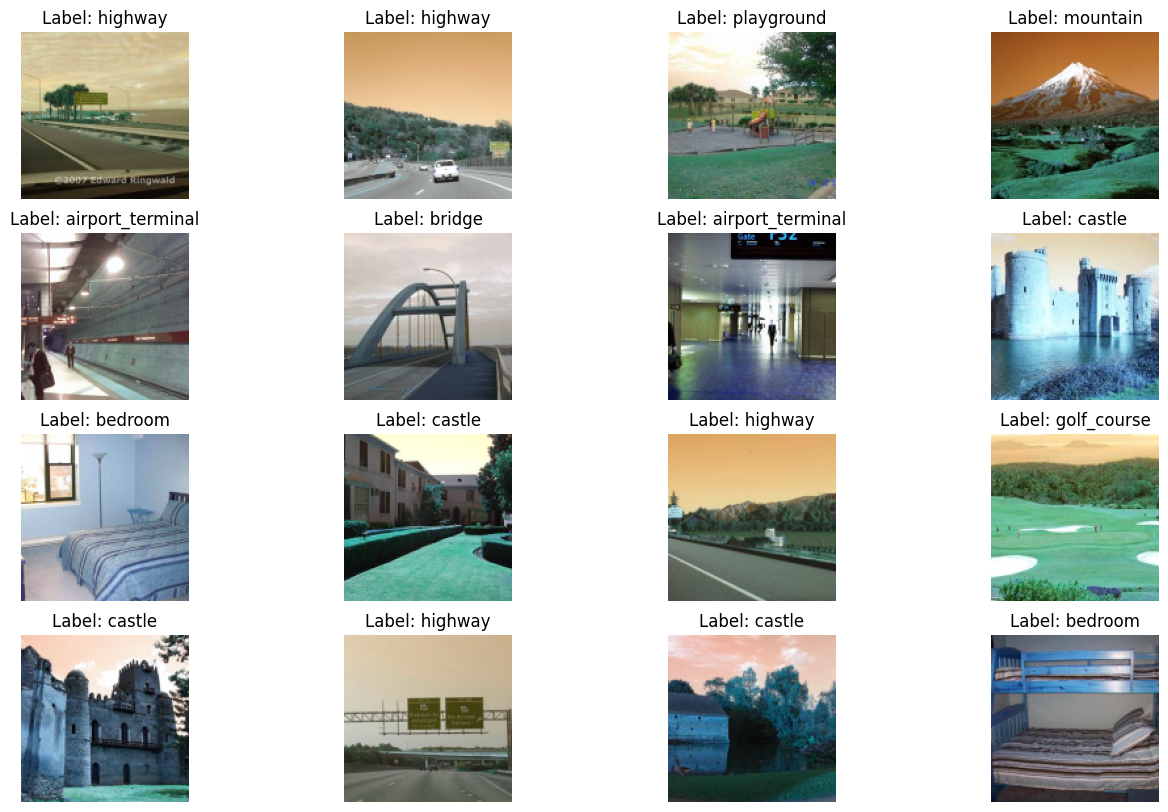

In [8]:
# A list with the names of the image classes
label_names = ['airport_terminal', 'amusement_park', 'bedroom', 'bridge', 'castle', 'conference_room',
               'golf_course', 'highway', 'mountain', 'playground']

# Plot a few images to check if the labels make sense
plt.figure(figsize=(16, 10))
for n in range(16):
    i = np.random.randint(0, len(train_images), 1)
    ax = plt.subplot(4, 4, n+1)
    # Since the images are in [0,255] range, we use 'astype(np.uint8)' to plot them
    plt.imshow(train_images[i[0]].astype(np.uint8))
    plt.title('Label: ' + str(label_names[train_labels[i[0]]]))
    plt.axis('off')

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50

import datetime
now = datetime.datetime.now

In [10]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Add a global spatial average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Add a fully-connected layer
x = Dense(2048, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.25)(x)
# Add a softmax layer with 10 classes
predictions = Dense(10, activation='softmax')(x)

# The model
model = Model(inputs=base_model.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

# fit model
callbacks = [EarlyStopping(monitor='val_loss', patience=3)]

t = now()
history = model.fit(train_images, train_labels, epochs=100, batch_size=64,
                     validation_data=[val_images, val_labels], verbose=1, callbacks=callbacks)
print('\nTraining time: %s' % (now() - t))

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 103s 910ms/step - accuracy: 0.6999 - loss: 0.9455 - val_accuracy: 0.8169 - val_loss: 0.8284
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.9559 - loss: 0.1509 - val_accuracy: 0.8676 - val_loss: 0.5517
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - accuracy: 0.9852 - loss: 0.0565 - val_accuracy: 0.8859 - val_loss: 0.4448
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 208ms/step - accuracy: 0.9965 - loss: 0.0185 - val_accuracy: 0.9127 - val_loss: 0.3986
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - accuracy: 0.9989 - loss: 0.0067 - val_accuracy: 0.9056 - val_loss: 0.3818
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.8986 - val_loss: 0.4294
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.8972 - val_loss: 0.4410
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.9947 - loss: 0.0193 - val

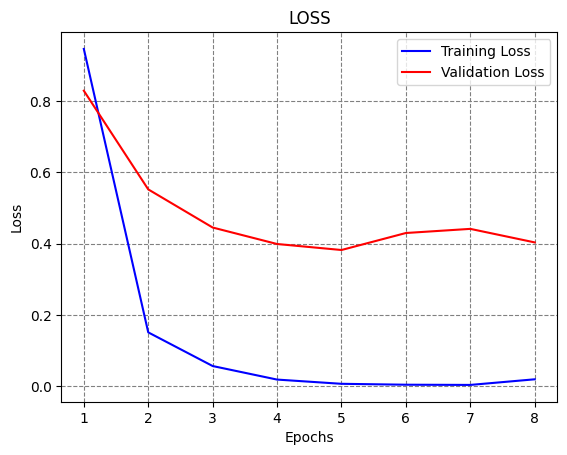

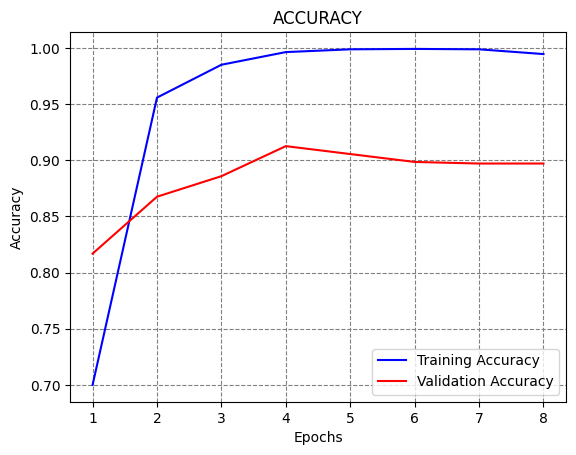

In [12]:
# Plot the loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.figure()
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [13]:
# Evaluate on test images
evals_test = model.evaluate(test_images, test_labels)
print("Classification Accuracy: ", evals_test[1])

28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.9019 - loss: 0.4110
Classification Accuracy:  0.9019165635108948


# Boundary Attack

In [14]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import BoundaryAttack

In [15]:
# TensorFlowV2Classifier requires to specify the number of classes, input shape, and values of the inputs
classifier = TensorFlowV2Classifier(model=model, nb_classes=10, input_shape=(128, 128, 3), clip_values=(0, 255))

## Boundary Untargeted Attack

In [16]:
label_names = ['airport_terminal', 'amusement_park', 'bedroom', 'bridge', 'castle', 'conference_room',
               'golf_course', 'highway', 'mountain', 'playground']

The true class of the target image is: airport_terminal
The predicted class of the target image is:  airport_terminal


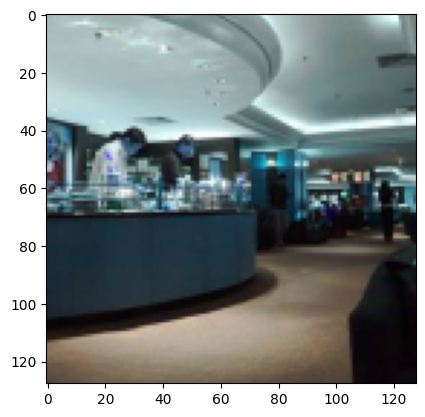

In [17]:
# Let's use the first test images to create an adversarial example
# Plot the image and display the true and predicted class
target_image = test_images[1].astype(np.uint8)
print('The true class of the target image is: ' + label_names[test_labels[1]])
print("The predicted class of the target image is: ", label_names[np.argmax(classifier.predict([target_image]))])
plt.imshow(target_image)
plt.show()

In [18]:
# Check the class label of the target image
print("Label of the target image is: ", np.argmax(classifier.predict(np.array([target_image]))[0]))

Label of the target image is:  0


Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations: 0it [00:00, ?it/s]

Adversarial image at step 0. L2 error 22074.703 and class label 1.
The label is amusement_park


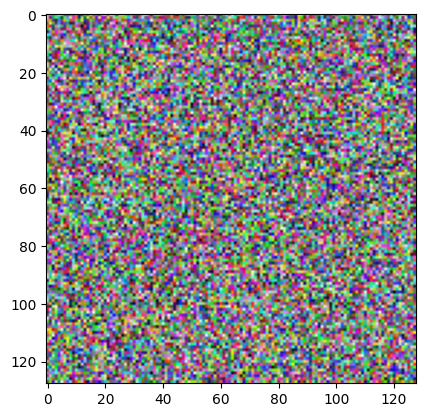

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 200. L2 error 28.43385 and class label 5.
The label is conference_room


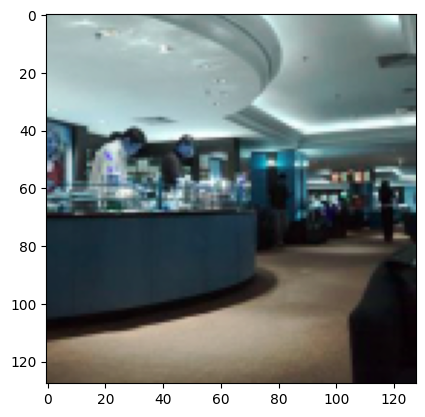

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 400. L2 error 17.082466 and class label 5.
The label is conference_room


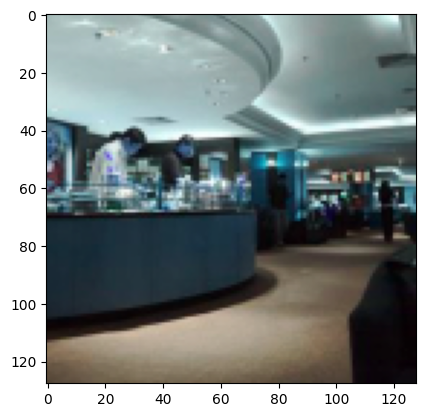

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 600. L2 error 13.2233925 and class label 5.
The label is conference_room


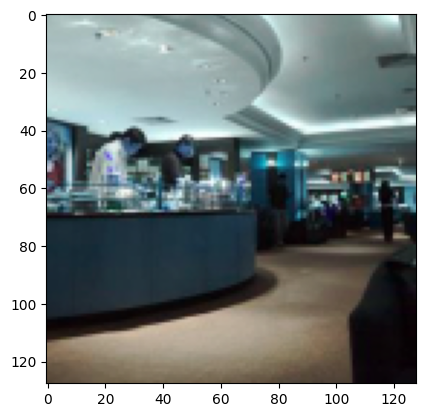

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 800. L2 error 11.393714 and class label 5.
The label is conference_room


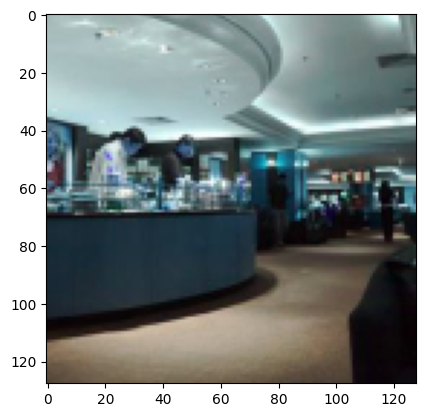

Attack time: 0:03:15.394160


In [19]:
t = now()

attack = BoundaryAttack(estimator=classifier, targeted=False, max_iter=0, delta=0.5, epsilon=0.3)
iter_step = 200
x_adv = None
for i in range(5):
    x_adv = attack.generate(x=np.array([target_image]), x_adv_init=x_adv)
    # print the norm of the perturbation and show the perturbed image
    print("Adversarial image at step %d." % (i * iter_step), "L2 error",
          np.linalg.norm(np.reshape(x_adv[0] - target_image, [-1])),
          "and class label %d." % np.argmax(classifier.predict(x_adv)[0]))
    print('The label is', label_names[np.argmax(classifier.predict(x_adv)[0])])
    plt.imshow(x_adv[0].astype(np.uint8))
    plt.show(block=False)

    if hasattr(attack, 'curr_delta') and hasattr(attack, 'curr_epsilon'):
        attack.max_iter = iter_step
        attack.delta = attack.curr_delta
        attack.epsilon = attack.curr_epsilon
    else:
        break

print('Attack time: %s' % (now() - t))

The predicted class of the target image is:  conference_room


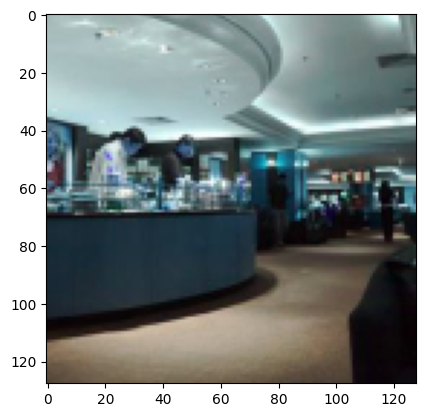

In [20]:
print("The predicted class of the target image is: ", label_names[np.argmax(classifier.predict(x_adv))])
plt.imshow(x_adv[0].astype(np.uint8))
plt.show()

## Boundary Targeted Attack

The true class of the target image is: airport_terminal
The predicted class of the target image is:  airport_terminal


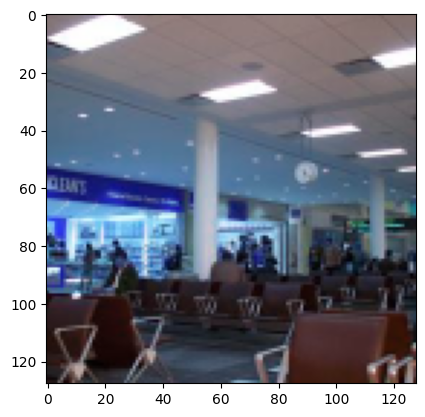

In [21]:
# Select a target image to create an adversarial example
target_image = test_images[10].astype(float)
print('The true class of the target image is: ' + label_names[test_labels[10]])
print("The predicted class of the target image is: ", label_names[np.argmax(classifier.predict([target_image]))])
plt.imshow(target_image.astype(np.uint8))
plt.show()

The true class of the initial image is: bedroom
The predicted class of the initial image is:  bedroom


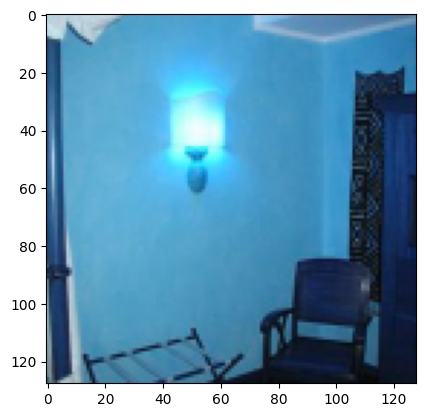

In [22]:
# Select one image from the target class as initial image
init_image = test_images[5]
print('The true class of the initial image is: ' + label_names[test_labels[5]])
print("The predicted class of the initial image is: ", label_names[np.argmax(classifier.predict(np.expand_dims(init_image, axis=0)))])
plt.imshow(init_image.astype(np.uint8))
plt.show()

In [23]:
# Check the class label of the initial image
print("Label of the initial image is: ", np.argmax(classifier.predict(np.array([init_image]))[0]))

Label of the initial image is:  2


Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations: 0it [00:00, ?it/s]

Adversarial image at step 0. L2 error 15905.6316127339 and class label 2.
The label is bedroom


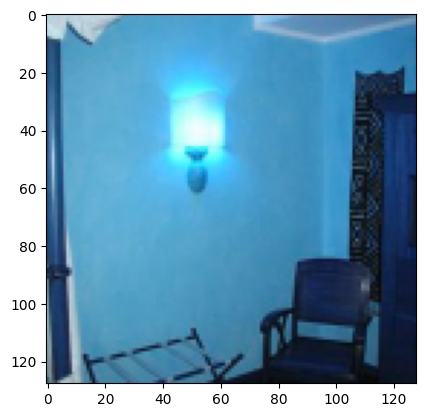

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 200. L2 error 1638.4147149979553 and class label 2.
The label is bedroom


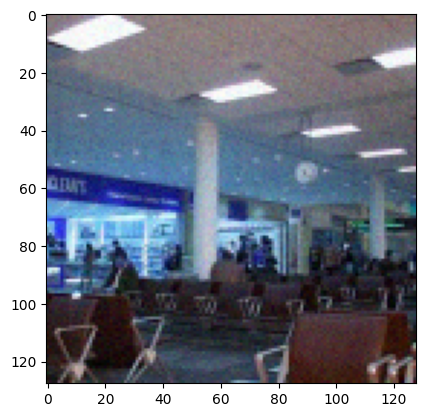

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 400. L2 error 1139.9544748054457 and class label 2.
The label is bedroom


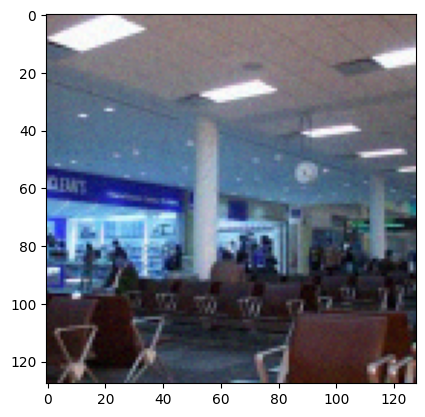

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 600. L2 error 918.2410406427243 and class label 2.
The label is bedroom


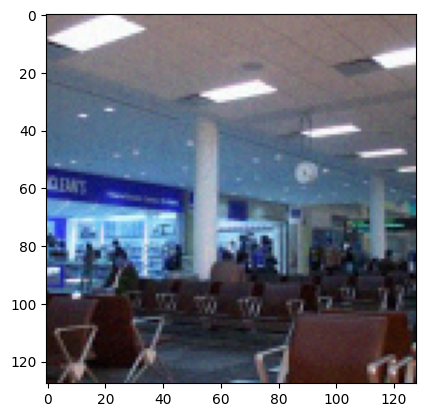

Boundary attack:   0%|          | 0/1 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Adversarial image at step 800. L2 error 788.4534438908466 and class label 2.
The label is bedroom


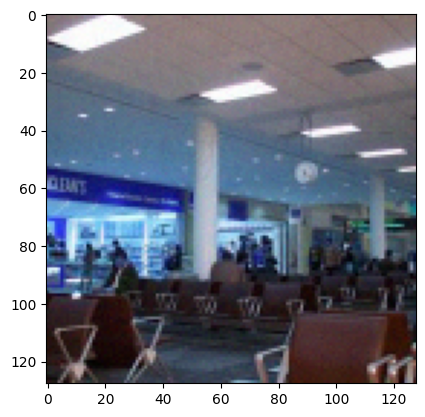

Attack time: 0:06:50.538202


In [24]:
from tensorflow.keras.utils import to_categorical

attack = BoundaryAttack(estimator=classifier, targeted=True, max_iter=0, delta=0.5, epsilon=0.3)
iter_step = 200
x_adv = np.expand_dims(init_image, axis=0)

for i in range(5):
    x_adv = attack.generate(x=np.expand_dims(target_image, axis=0), y=to_categorical([2], 10), x_adv_init=x_adv)

    # print the norm of the perturbation and show the perturbed image
    print("Adversarial image at step %d." % (i * iter_step), "L2 error",
          np.linalg.norm(np.reshape(x_adv[0] - target_image, [-1])),
          "and class label %d." % np.argmax(classifier.predict(x_adv)[0]))
    print('The label is', label_names[np.argmax(classifier.predict(x_adv)[0])])
    plt.imshow(x_adv[0].astype(np.uint8))
    plt.show(block=False)

    if hasattr(attack, 'curr_delta') and hasattr(attack, 'curr_epsilon'):
        attack.max_iter = iter_step
        attack.delta = attack.curr_delta
        attack.epsilon = attack.curr_epsilon
    else:
        break

print('Attack time: %s' % (now() - t))

The predicted class of the target image is:  bedroom


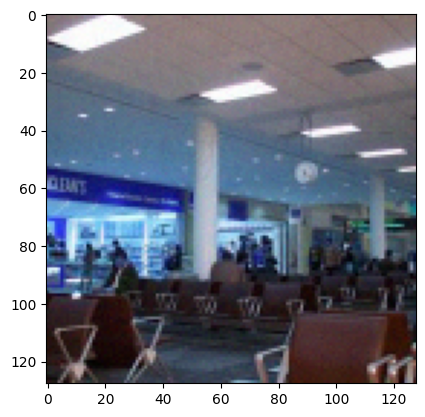

In [25]:
print("The predicted class of the target image is: ", label_names[np.argmax(classifier.predict(x_adv))])
plt.imshow(x_adv[0].astype(int))
plt.show()